**Ejercicio 1**
Implementar un auto codificador para las imagenes binarias de la lista de caracteres
del archivo “caracteres.h”

##Ejercicio 1

Cantidad hex: 224
Font1: (32, 7)
X: (32, 35)

Caracter: $
[[0 0 1 0 0]
 [0 1 1 1 1]
 [1 0 1 0 0]
 [0 1 1 1 0]
 [0 0 1 0 1]
 [1 1 1 1 0]
 [0 0 1 0 0]]


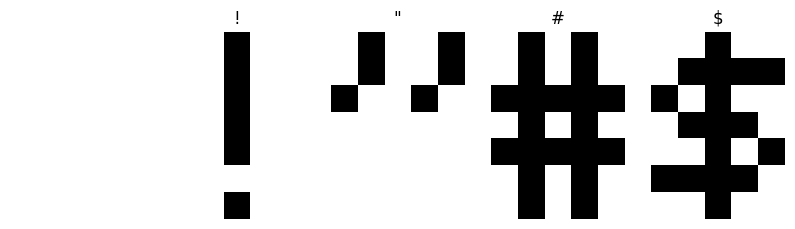

In [ ]:
# @title Carga y conversión de Font1

import numpy as np
import re
import matplotlib.pyplot as plt

with open('/content/caracteres.txt',
          'r',
          encoding='utf-8') as f:
    texto = f.read()

# SACAR SOLO Font1
bloque = texto.split("int const Font1[32][7] = {")[1]
bloque = bloque.split("};")[0]

# ELIMINAR COMENTARIOS //
bloque = re.sub(
    r'//.*',
    '',
    bloque
)

# EXTRAER HEX
hexs = re.findall(
    r'0x[0-9a-fA-F]+',
    bloque
)

print("Cantidad hex:", len(hexs))

# ARMAR FONT1
font1=[]
for i in range(0, len(hexs), 7):

    filas=[
        int(x,16)
        for x in hexs[i:i+7]
    ]

    font1.append(filas)

font1=np.array(font1)

print("Font1:", font1.shape)


# HEX -> PIXELES

def convertir_fuente(font):
    patrones=[]

    for caracter in font:
        pixels=[]
        for fila in caracter:
            bits=[
                (fila >> b) & 1
                for b in range(4,-1,-1)
            ]

            pixels.extend(bits)
        patrones.append(pixels)

    return np.array(
        patrones,
        dtype=np.float32
    )
X = convertir_fuente(font1)


print("X:",X.shape)




# ETIQUETAS

etiquetas=[
    chr(i)
    for i in range(0x20,0x20+32)
]


# PROBAR $

idx=etiquetas.index('$')

print("\nCaracter:", etiquetas[idx])

print(
    X[idx]
    .reshape(7,5)
    .astype(int)
)




# VISUALIZAR PRIMEROS

plt.figure(figsize=(10,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        X[i].reshape(7,5),
        cmap="gray_r"
    )

    plt.title(etiquetas[i])
    plt.axis("off")


plt.show()


MSE final: 0.01701849140226841

Original (muestra 1):
[[0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]

Reconstruccion (muestra 1):
[[0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]

Forma espacio latente:
(32, 2)


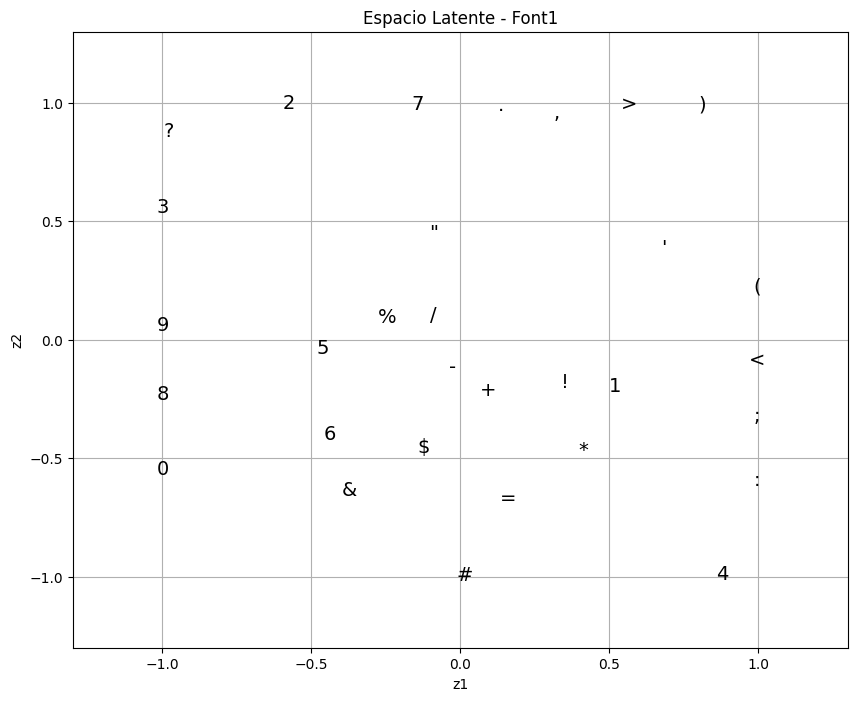

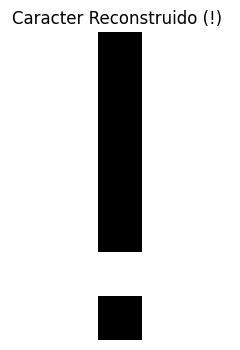

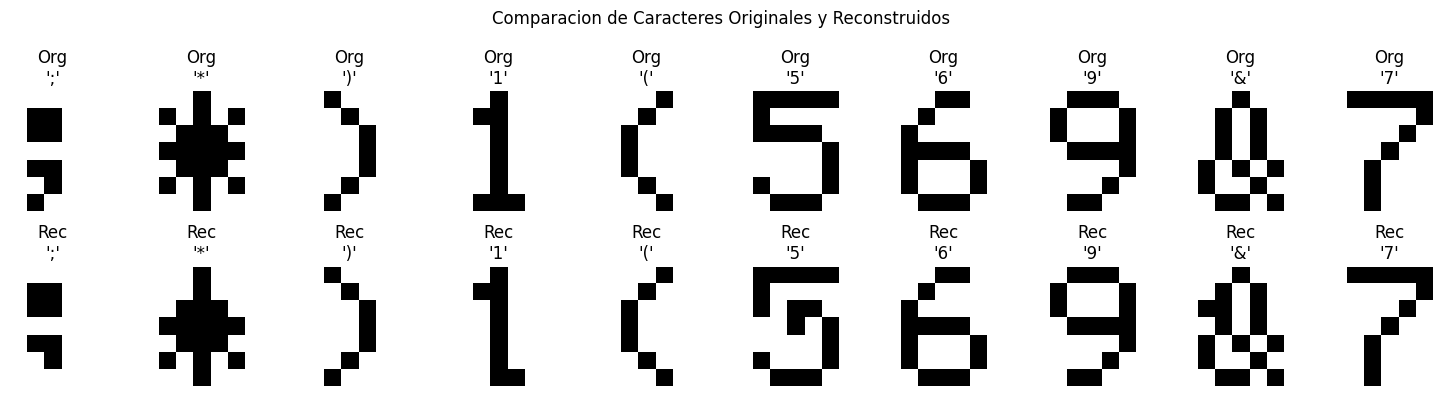

In [ ]:
# @title Autoencoder Font1 y espacio latente 2D

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# AUTOENCODER
# 35 -> 20 -> 10 -> 2 -> 10 -> 20 -> 35

entrada = Input(shape=(35,)) #Vector de longitud 35, eso hace shape. Acá se define la entrada

# Encoder
x = Dense(20, activation='tanh')(entrada)
x = Dense(10, activation='tanh')(x)
latente = Dense(2, activation='tanh', name='latent')(x)

# Decoder
x = Dense(10, activation='tanh')(latente)
x = Dense(20, activation='tanh')(x)
salida = Dense(35, activation='sigmoid')(x)

autoencoder = Model(entrada, salida) #La red epieza en entrada y termina en salida

autoencoder.compile(   #Se configura como aprende
    optimizer='adam', #algoritmo que modifica los pesos
    loss='mse'
)

# ENTRENAMIENTO
historia = autoencoder.fit(
    X,
    X,
    epochs=5000,
    verbose=0   #ver epocas, en 0 no imprie nada
)


# ERROR FINAL
mse = autoencoder.evaluate(X, X, verbose=0)
print("\nMSE final:", mse)


# RECONSTRUCCION
reconstruccion = autoencoder.predict(X, verbose=0)

reconstruccion_binaria = (   #Umbral, pasa las probabilidades de cada valor a un valor fijo, 0 o 1.
    reconstruccion > 0.5
).astype(int)

muestra = 1

print(f"\nOriginal (muestra {muestra}):")
print(X[muestra].reshape(7,5).astype(int))

print(f"\nReconstruccion (muestra {muestra}):")
print(reconstruccion_binaria[muestra].reshape(7,5))


# ENCODER

encoder = Model(      #obtenés directamente la representación comprimida de cada carácter. En vez de llegar hasta la salida de 35 neuronas, este modelo termina en la capa llamada "latent".
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent").output
)

latentes = encoder.predict(X, verbose=0)

print("\nForma espacio latente:")
print(latentes.shape)

# GRAFICO ESPACIO LATENTE

plt.figure(figsize=(10,8))

for i, caracter in enumerate(etiquetas):
    plt.text(
        latentes[i,0],
        latentes[i,1],
        caracter,
        fontsize=14,
        ha='center',
        va='center'
    )

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Espacio Latente - Font1")
plt.grid(True)

# margen fijo para que no corte etiquetas
plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)

plt.show()


# DECODER INDEPENDIENTE
entrada_latente = Input(shape=(2,))

x = autoencoder.layers[4](entrada_latente)
x = autoencoder.layers[5](x)
salida_decoder = autoencoder.layers[6](x)

decoder = Model(
    entrada_latente,
    salida_decoder
)


plt.figure(figsize=(3,4))

plt.imshow(
    reconstruccion_binaria[muestra].reshape(7,5),
    cmap="gray_r"
)

plt.title(f"Caracter Reconstruido ({etiquetas[muestra]}) ")
plt.axis("off")

plt.show()




n_caracteres = 10 # Número de caracteres a mostrar
indices_to_show = np.random.choice(len(X), n_caracteres, replace=False)

plt.figure(figsize=(n_caracteres * 1.5, 4))
for i, idx in enumerate(indices_to_show):
    # Original
    ax = plt.subplot(2, n_caracteres, i + 1)
    plt.imshow(X[idx].reshape(7, 5), cmap='gray_r')
    plt.title(f"Org\n'{etiquetas[idx]}'")
    plt.axis('off')

    # Reconstruido
    ax = plt.subplot(2, n_caracteres, i + 1 + n_caracteres)
    plt.imshow(reconstruccion_binaria[idx].reshape(7, 5), cmap='gray_r')
    plt.title(f"Rec\n'{etiquetas[idx]}'")
    plt.axis('off')

plt.suptitle('Comparacion de Caracteres Originales y Reconstruidos')
print()
plt.tight_layout()

plt.show()

Punto elegido en espacio latente:
[[ 1.  -0.7]]

Caracter generado:
[[0 0 0 0 0]
 [0 1 1 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]
 [0 1 1 0 0]
 [0 1 1 0 0]
 [0 0 0 1 0]]


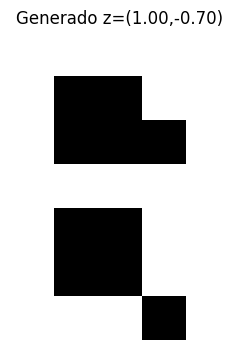

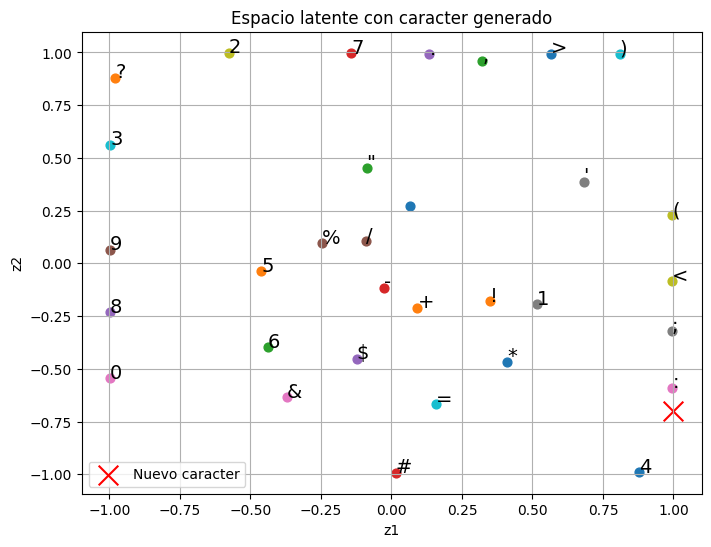

In [ ]:
# @title Generación de un carácter desde el espacio latente

punto = np.array([[1, -0.7]])


# Decodificar
generado = decoder.predict(
    punto,
    verbose=0
)


# Pasar a binario
generado_binario = (
    generado > 0.5
).astype(int)


print("Punto elegido en espacio latente:")
print(punto)

print("\nCaracter generado:")
print(generado_binario.reshape(7,5))



# MOSTRAR CARACTER GENERADO

plt.figure(figsize=(3,4))

plt.imshow(
    generado_binario.reshape(7,5),
    cmap="gray_r"
)

plt.title(
    f"Generado z=({punto[0,0]:.2f},{punto[0,1]:.2f})"
)

plt.axis("off")
plt.show()



# PLANO LATENTE CON PUNTO NUEVO

plt.figure(figsize=(8,6))


# Mostrar caracteres aprendidos
for i, caracter in enumerate(etiquetas):

    plt.scatter(
        latentes[i,0],
        latentes[i,1],
        s=40
    )

    plt.text(
        latentes[i,0],
        latentes[i,1],
        caracter,
        fontsize=14
    )


# Punto generado
plt.scatter(
    punto[0,0],
    punto[0,1],
    c="red",
    s=200,
    marker="x",
    label="Nuevo caracter"
)


plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Espacio latente con caracter generado")
plt.legend()
plt.grid(True)

plt.show()

##Ejercicio 2

In [ ]:
# @title Ejercicio 2 - Autoencoder eliminador de ruido

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# ==================================
# PARAMETROS PARA MODIFICAR
# ==================================

RUIDO_MIN = 0.02
RUIDO_MAX = 0.15

COPIAS_POR_CARACTER = 200
EPOCHS = 700
BATCH_SIZE = 32

NEURONAS_1 = 20
NEURONAS_2 = 15
NEURONAS_LATENTE = 10

np.random.seed(42)


# ==================================
# DATOS LIMPIOS DEL EJERCICIO 1
# ==================================

X_limpio = np.array(X, dtype=np.float32).copy()
etiquetas_limpio = etiquetas.copy()

print("Forma X_limpio:", X_limpio.shape)


# ==================================
# RUIDO BINARIO
# ==================================
# Cada píxel tiene probabilidad "nivel" de invertirse.
# 0 -> 1
# 1 -> 0

def agregar_ruido(X, nivel):
    X_ruidoso = X.copy()

    mascara = np.random.random(X.shape) < nivel

    X_ruidoso[mascara] = 1 - X_ruidoso[mascara]

    return X_ruidoso.astype(np.float32)


# ==================================
# DATASET DE ENTRENAMIENTO
# ==================================
# Entrada: carácter con ruido
# Salida esperada: el mismo carácter limpio

X_ruido_train = []
X_limpio_train = []

for patron in X_limpio:

    for _ in range(COPIAS_POR_CARACTER):

        nivel = np.random.uniform(RUIDO_MIN, RUIDO_MAX)

        patron_ruidoso = agregar_ruido(
            patron.reshape(1, 35),
            nivel
        )[0]

        X_ruido_train.append(patron_ruidoso)
        X_limpio_train.append(patron)

X_ruido_train = np.array(X_ruido_train, dtype=np.float32)
X_limpio_train = np.array(X_limpio_train, dtype=np.float32)

print("Entradas con ruido:", X_ruido_train.shape)
print("Salidas limpias  :", X_limpio_train.shape)


# ==================================
# AUTOENCODER
# ==================================
# Entrada ruidosa -> salida limpia
#
# Arquitectura:
# 35 -> NEURONAS_1 -> NEURONAS_2 -> NEURONAS_LATENTE
#    -> NEURONAS_2 -> NEURONAS_1 -> 35

entrada = Input(shape=(35,))

# Encoder
x = Dense(NEURONAS_1, activation="tanh")(entrada)
x = Dense(NEURONAS_2, activation="tanh")(x)
latente_ruido = Dense(
    NEURONAS_LATENTE,
    activation="tanh",
    name="latent_ruido"
)(x)

# Decoder
x = Dense(NEURONAS_2, activation="tanh")(latente_ruido)
x = Dense(NEURONAS_1, activation="tanh")(x)
salida = Dense(35, activation="sigmoid")(x)

autoencoder_ruido = Model(entrada, salida)

autoencoder_ruido.compile(
    optimizer="adam",
    loss="mse"
)


# ==================================
# ENTRENAMIENTO
# ==================================

autoencoder_ruido.fit(
    X_ruido_train,
    X_limpio_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=0
)

print("Entrenamiento terminado")
print("Ruido usado en entrenamiento:", RUIDO_MIN, "a", RUIDO_MAX)
print("Latente:", NEURONAS_LATENTE)

Forma X_limpio: (32, 35)
Entradas con ruido: (6400, 35)
Salidas limpias  : (6400, 35)
Entrenamiento terminado
Ruido usado en entrenamiento: 0.02 a 0.15
Latente: 10


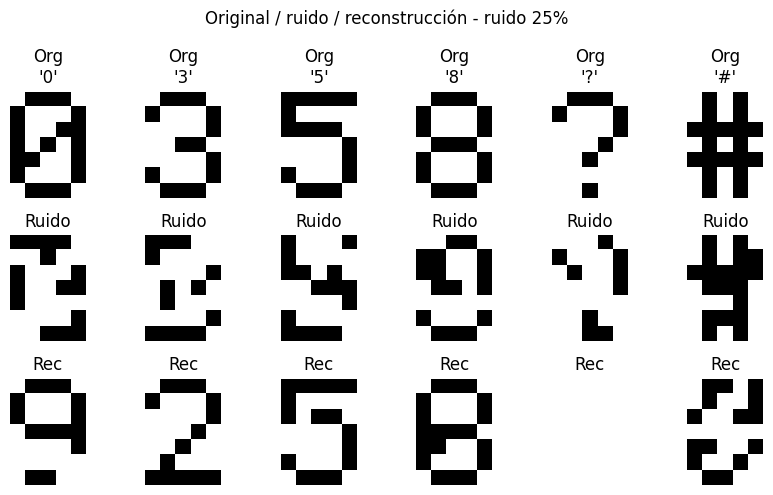

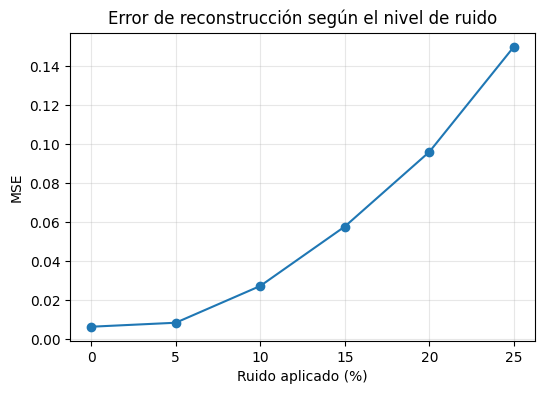

In [ ]:
# @title Ejercicio 2 - Prueba visual de eliminación de ruido

NIVEL_MOSTRAR = 0.25

caracteres_mostrar = ['0', '3', '5', '8', '?', '#']

indices = [
    etiquetas_limpio.index(c)
    for c in caracteres_mostrar
]

X_ruidoso = agregar_ruido(
    X_limpio[indices],
    NIVEL_MOSTRAR
)

reconstruccion = autoencoder_ruido.predict(
    X_ruidoso,
    verbose=0
)

reconstruccion_binaria = (
    reconstruccion > 0.5
).astype(int)

n_caracteres = len(indices)

plt.figure(figsize=(n_caracteres * 1.4, 5))

for i, idx in enumerate(indices):

    plt.subplot(3, n_caracteres, i + 1)
    plt.imshow(X_limpio[idx].reshape(7, 5), cmap="gray_r")
    plt.title(f"Org\n'{etiquetas_limpio[idx]}'")
    plt.axis("off")

    plt.subplot(3, n_caracteres, i + 1 + n_caracteres)
    plt.imshow(X_ruidoso[i].reshape(7, 5), cmap="gray_r")
    plt.title("Ruido")
    plt.axis("off")

    plt.subplot(3, n_caracteres, i + 1 + 2 * n_caracteres)
    plt.imshow(reconstruccion_binaria[i].reshape(7, 5), cmap="gray_r")
    plt.title("Rec")
    plt.axis("off")

plt.suptitle(
    f"Original / ruido / reconstrucción - ruido {NIVEL_MOSTRAR*100:.0f}%"
)

plt.tight_layout()
plt.show()

# ==================================
# GRAFICO SIMPLE: RUIDO vs ERROR
# ==================================
# Este gráfico no entrena de nuevo.
# Solo prueba el autoencoder ya entrenado con distintos niveles de ruido.

niveles_grafico = np.arange(
    0.00,
    NIVEL_MOSTRAR + 0.001,
    0.05
)

mse_por_ruido = []

repeticiones = 20

for nivel in niveles_grafico:

    errores = []

    for _ in range(repeticiones):

        X_ruidoso_eval = agregar_ruido(
            X_limpio,
            nivel
        )

        reconstruccion_eval = autoencoder_ruido.predict(
            X_ruidoso_eval,
            verbose=0
        )

        mse = np.mean(
            (X_limpio - reconstruccion_eval) ** 2
        )

        errores.append(mse)

    mse_por_ruido.append(
        np.mean(errores)
    )


plt.figure(figsize=(6, 4))

plt.plot(
    niveles_grafico * 100,
    mse_por_ruido,
    marker="o"
)

plt.title("Error de reconstrucción según el nivel de ruido")
plt.xlabel("Ruido aplicado (%)")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)

plt.show()

##Ejercicio 3


Forma de X: (32, 35)
MSE final generativo: 0.049794063940860084


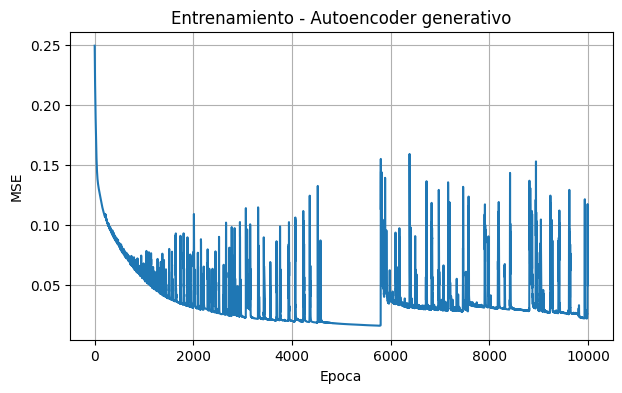

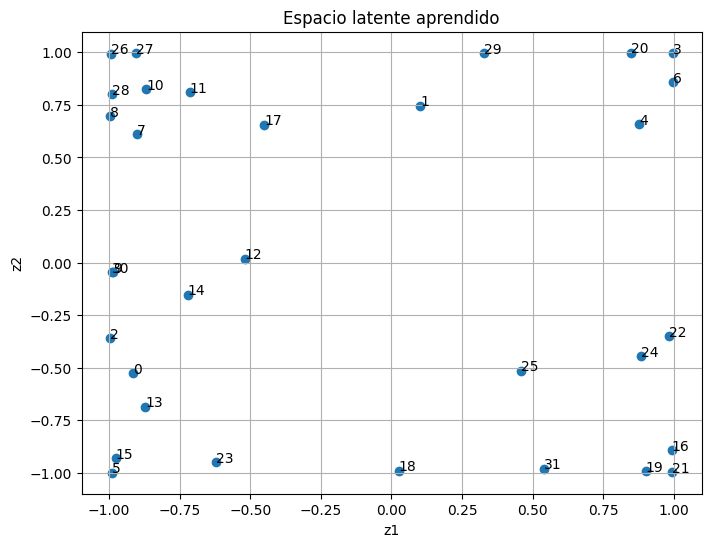

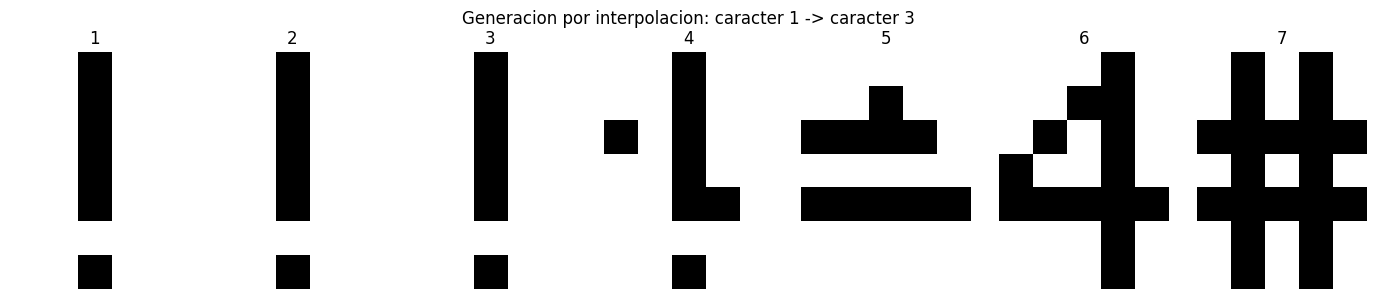

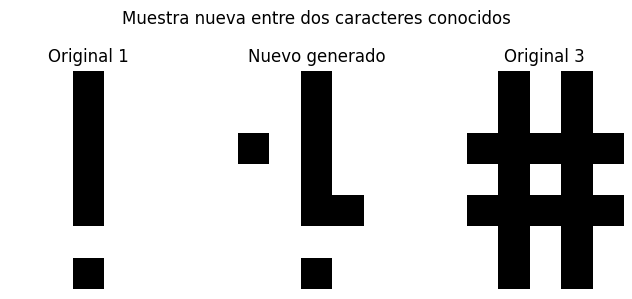

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

print("Forma de X:", X.shape)  # esperado: (32, 35)

# =========================
# ACTIVACIONES
# =========================

def tanh(x):
    return np.tanh(x)

def d_tanh(y):
    return 1 - y**2

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(y):
    return y * (1 - y)

np.random.seed(42)

W1_g = np.random.uniform(-0.5, 0.5, (20, 35))
W2_g = np.random.uniform(-0.5, 0.5, (10, 20))
W3_g = np.random.uniform(-0.5, 0.5, (2, 10))

W4_g = np.random.uniform(-0.5, 0.5, (10, 2))
W5_g = np.random.uniform(-0.5, 0.5, (20, 10))
W6_g = np.random.uniform(-0.5, 0.5, (35, 20))

b1_g = np.zeros((20, 1))
b2_g = np.zeros((10, 1))
b3_g = np.zeros((2, 1))
b4_g = np.zeros((10, 1))
b5_g = np.zeros((20, 1))
b6_g = np.zeros((35, 1))

lr = 0.01
epochs = 10000
errores = []

# =========================
# FUNCIONES ENCODER / DECODER
# =========================

def encoder(x):
    a1 = tanh(W1_g @ x + b1_g)
    a2 = tanh(W2_g @ a1 + b2_g)
    z = tanh(W3_g @ a2 + b3_g)
    return z

def decoder(z):
    a4 = tanh(W4_g @ z + b4_g)
    a5 = tanh(W5_g @ a4 + b5_g)
    y = sigmoid(W6_g @ a5 + b6_g)
    return y

def autoencoder(x):
    z = encoder(x)
    y = decoder(z)
    return y, z


for epoch in range(epochs):
    mse = 0

    for patron in X:
        x = patron.reshape(35, 1)
        target = x

        # Forward
        a1 = tanh(W1_g @ x + b1_g)
        a2 = tanh(W2_g @ a1 + b2_g)
        z = tanh(W3_g @ a2 + b3_g)

        a4 = tanh(W4_g @ z + b4_g)
        a5 = tanh(W5_g @ a4 + b5_g)
        y = sigmoid(W6_g @ a5 + b6_g)

        # Error
        error = target - y
        mse += np.mean(error**2)

        # Backprop
        delta6 = error * d_sigmoid(y)
        delta5 = (W6_g.T @ delta6) * d_tanh(a5)
        delta4 = (W5_g.T @ delta5) * d_tanh(a4)
        delta3 = (W4_g.T @ delta4) * d_tanh(z)
        delta2 = (W3_g.T @ delta3) * d_tanh(a2)
        delta1 = (W2_g.T @ delta2) * d_tanh(a1)

        # Actualizacion
        W6_g += lr * (delta6 @ a5.T)
        W5_g += lr * (delta5 @ a4.T)
        W4_g += lr * (delta4 @ z.T)
        W3_g += lr * (delta3 @ a2.T)
        W2_g += lr * (delta2 @ a1.T)
        W1_g += lr * (delta1 @ x.T)

        b6_g += lr * delta6
        b5_g += lr * delta5
        b4_g += lr * delta4
        b3_g += lr * delta3
        b2_g += lr * delta2
        b1_g += lr * delta1

    mse /= len(X)
    errores.append(mse)

print("MSE final generativo:", errores[-1])

plt.figure(figsize=(7, 4))
plt.plot(errores)
plt.title("Entrenamiento - Autoencoder generativo")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

latentes = []

for patron in X:
    x = patron.reshape(35, 1)
    z = encoder(x)
    latentes.append(z.flatten())

latentes = np.array(latentes)

plt.figure(figsize=(8, 6))
plt.scatter(latentes[:, 0], latentes[:, 1])

for i in range(len(latentes)):
    plt.annotate(str(i), (latentes[i, 0], latentes[i, 1]))

plt.title("Espacio latente aprendido")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True)
plt.show()

idx_a = 1
idx_b = 3
pasos = 7

z_a = latentes[idx_a].reshape(2, 1)
z_b = latentes[idx_b].reshape(2, 1)

generados = []

for alpha in np.linspace(0, 1, pasos):
    z_nuevo = (1 - alpha) * z_a + alpha * z_b
    y_nuevo = decoder(z_nuevo)
    y_binario = (y_nuevo > 0.5).astype(int)
    generados.append(y_binario.reshape(7, 5))

fig, axes = plt.subplots(1, pasos, figsize=(2 * pasos, 3))

for i, img in enumerate(generados):
    axes[i].imshow(img, cmap="gray_r")
    axes[i].axis("off")
    axes[i].set_title(f"{i+1}")

plt.suptitle(f"Generacion por interpolacion: caracter {idx_a} -> caracter {idx_b}")
plt.tight_layout()
plt.show()


# Mostramos los caracteres reales de los extremos y las muestras generadas.

fig, axes = plt.subplots(1, 3, figsize=(7, 3))

axes[0].imshow(X[idx_a].reshape(7, 5), cmap="gray_r")
axes[0].set_title(f"Original {idx_a}")
axes[0].axis("off")

axes[1].imshow(generados[len(generados)//2], cmap="gray_r")
axes[1].set_title("Nuevo generado")
axes[1].axis("off")

axes[2].imshow(X[idx_b].reshape(7, 5), cmap="gray_r")
axes[2].set_title(f"Original {idx_b}")
axes[2].axis("off")

plt.suptitle("Muestra nueva entre dos caracteres conocidos")
plt.tight_layout()
plt.show()

In [ ]:
# @title
import numpy as np

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# ==================================
# RUIDO
# ==================================

def agregar_ruido(X, nivel):

    X_ruidoso = X.copy()

    mascara = np.random.rand(*X.shape) < nivel

    X_ruidoso[mascara] = 1 - X_ruidoso[mascara]

    return X_ruidoso


# ==================================
# GENERAR DATASET GRANDE
# ==================================

X_train = []
Y_train = []

copias_por_caracter = 50

for patron in X:

    for _ in range(copias_por_caracter):

        nivel = np.random.uniform(0.05, 0.35)

        ruidoso = agregar_ruido(
            patron.reshape(1,35),
            nivel
        )[0]

        X_train.append(ruidoso)
        Y_train.append(patron)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

print("Entradas:", X_train.shape)
print("Salidas :", Y_train.shape)


# ==================================
# DENOISING AUTOENCODER
# ==================================

entrada = Input(shape=(35,))

# Encoder
x = Dense(
    20,
    activation="tanh"
)(entrada)

x = Dense(
    15,
    activation="tanh"
)(x)

latente = Dense(
    10,
    activation="tanh",
    name="latent"
)(x)

# Decoder
x = Dense(
    15,
    activation="tanh"
)(latente)

x = Dense(
    20,
    activation="tanh"
)(x)

salida = Dense(
    35,
    activation="sigmoid"
)(x)

denoising = Model(
    entrada,
    salida
)

denoising.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


# ==================================
# ENTRENAMIENTO
# ==================================

historia = denoising.fit(
    X_train,
    Y_train,
    epochs=500,
    batch_size=32,
    shuffle=True,
    verbose=1
)

print("Entrenamiento terminado")

Entradas: (1600, 35)
Salidas : (1600, 35)
Epoch 1/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6634
Epoch 2/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5962
Epoch 3/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5669
Epoch 4/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5310
Epoch 5/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4965
Epoch 6/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4769
Epoch 7/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4631
Epoch 8/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4508
Epoch 9/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4370
Epoch 10/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4250
Epoch 11/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4148
Epoch 12/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4059
Epoch 13/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3983
Epoch 14/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3929
Epoch 15/500
50/50 ━━━━━━━━━━

Caracter: 0
Ruido: 20.0 %

Original:
[[0 1 1 1 0]
 [1 0 0 0 1]
 [1 0 0 1 1]
 [1 0 1 0 1]
 [1 1 0 0 1]
 [1 0 0 0 1]
 [0 1 1 1 0]]

Con ruido:
[[0 1 0 1 0]
 [1 0 1 0 1]
 [1 0 1 1 1]
 [1 1 1 1 1]
 [1 1 0 0 0]
 [1 0 0 0 1]
 [0 1 1 0 0]]

Reconstruido:
[[0 0 1 1 0]
 [0 0 0 0 0]
 [1 0 0 0 0]
 [1 1 1 1 0]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [0 1 1 1 0]]


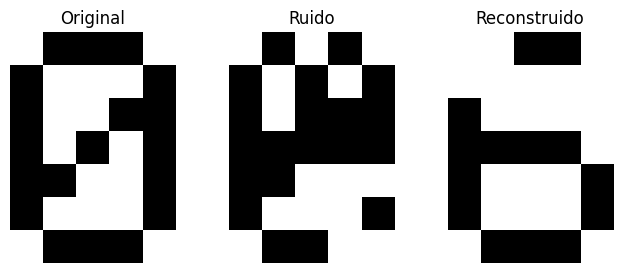

In [ ]:
# @title

# PROBAR UN CARACTER

def probar_ruido(caracter, porcentaje):

    # buscar posición del caracter
    indice = etiquetas.index(caracter)


    original = X[indice]


    # crear ruido nuevo
    entrada_ruidosa = agregar_ruido(
        original.reshape(1,35),
        porcentaje
    )


    # reconstrucción
    salida = denoising.predict(
        entrada_ruidosa,
        verbose=0
    )


    reconstruido = (
        salida > 0.5
    ).astype(int)



    print("Caracter:", caracter)
    print("Ruido:", porcentaje*100,"%")

    print("\nOriginal:")
    print(
        original.reshape(7,5).astype(int)
    )


    print("\nCon ruido:")
    print(
        entrada_ruidosa.reshape(7,5).astype(int)
    )


    print("\nReconstruido:")
    print(
        reconstruido.reshape(7,5)
    )

        # ==================================
    # MOSTRAR
    # ==================================

    plt.figure(figsize=(8,3))

    plt.subplot(1,3,1)
    plt.imshow(
        original.reshape(7,5),
        cmap="gray_r"
    )
    plt.title("Original")
    plt.axis("off")


    plt.subplot(1,3,2)
    plt.imshow(
        entrada_ruidosa.reshape(7,5),
        cmap="gray_r"
    )
    plt.title("Ruido")
    plt.axis("off")


    plt.subplot(1,3,3)
    plt.imshow(
        reconstruido.reshape(7,5),
        cmap="gray_r"
    )
    plt.title("Reconstruido")
    plt.axis("off")


    plt.show()

probar_ruido('0',0.20)

# Ejercicio 3 CORRECCIÓN

Cantidad hex: 224
Font4: (32, 7)
X: (32, 35)
0 ▲
1 ▼
2 ←
3 →
4 │

Caracter: +
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


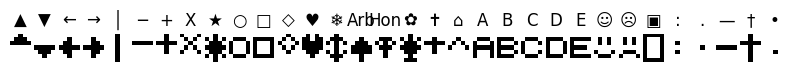

In [ ]:
import numpy as np
import re
import matplotlib.pyplot as plt

with open('/content/caracteresExtras.txt',
          'r',
          encoding='utf-8') as f:
    texto = f.read()



# ===============================
# SACAR SOLO Font4
# ===============================

bloque = texto.split("int const Font4[32][7] = {")[1]
bloque = bloque.split("};")[0]


# ELIMINAR COMENTARIOS //

bloque = re.sub(
    r'//.*',
    '',
    bloque
)

# EXTRAER HEX


hexs = re.findall(
    r'0x[0-9a-fA-F]+',
    bloque
)


print("Cantidad hex:", len(hexs))

# ARMAR FONT4

font4=[]

for i in range(0, len(hexs), 7):

    filas=[
        int(x,16)
        for x in hexs[i:i+7]
    ]

    font4.append(filas)


font4=np.array(font4)

print("Font4:", font4.shape)


# HEX -> PIXELES

def convertir_fuente(font):

    patrones=[]

    for caracter in font:

        pixels=[]

        for fila in caracter:

            bits=[
                (fila >> b) & 1
                for b in range(4,-1,-1)
            ]

            pixels.extend(bits)

        patrones.append(pixels)

    return np.array(
        patrones,
        dtype=np.float32
    )


X = convertir_fuente(font4)


print("X:",X.shape)




# ETIQUETAS
etiquetas = [
    "▲","▼","←","→",
    "│","─","+","X",
    "★","○","□","◇",
    "♥","❄","Arb","Hon",
    "✿","✝","⌂","A",
    "B","C","D","E",
    "☺","☹","▣",":",
    ".","—","†","•"
]

for i in range(5):
    print(i, etiquetas[i])


# PROBAR ▲

idx=etiquetas.index('+')

print("\nCaracter:", etiquetas[idx])

print(
    X[idx]
    .reshape(7,5)
    .astype(int)
)




# VISUALIZAR PRIMEROS

plt.figure(figsize=(10,3))

for i in range(32):

    plt.subplot(1,32,i+1)

    plt.imshow(
        X[i].reshape(7,5),
        cmap="gray_r"
    )

    plt.title(etiquetas[i])
    plt.axis("off")


plt.show()


MSE final: 0.008660197257995605

Original (index 1):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]

Reconstruccion (index 1):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]

Forma espacio latente:
(32, 2)


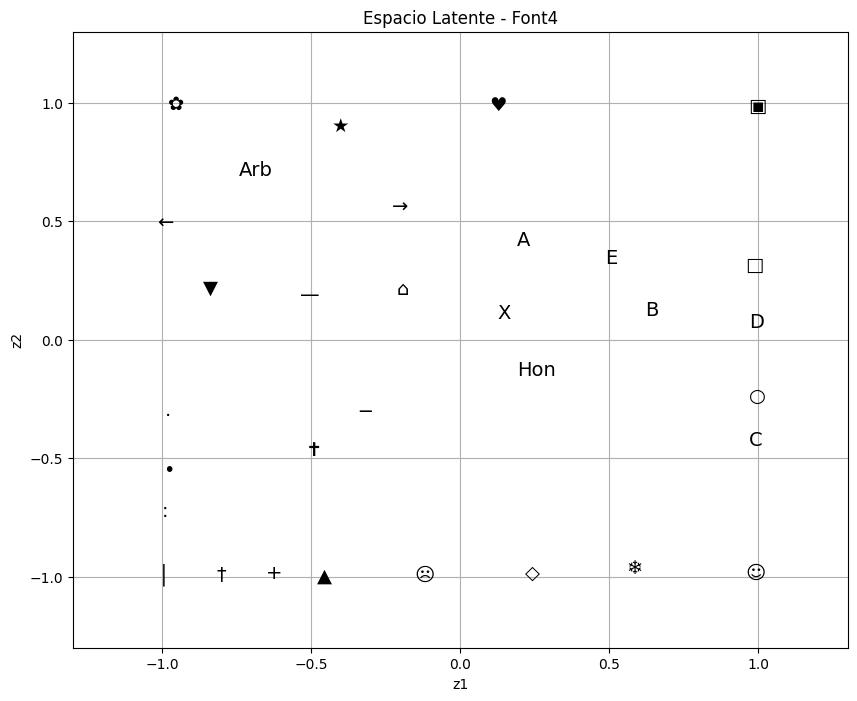

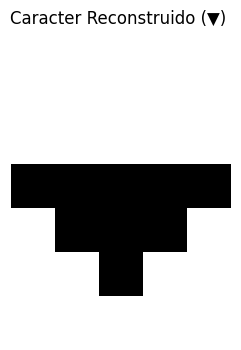

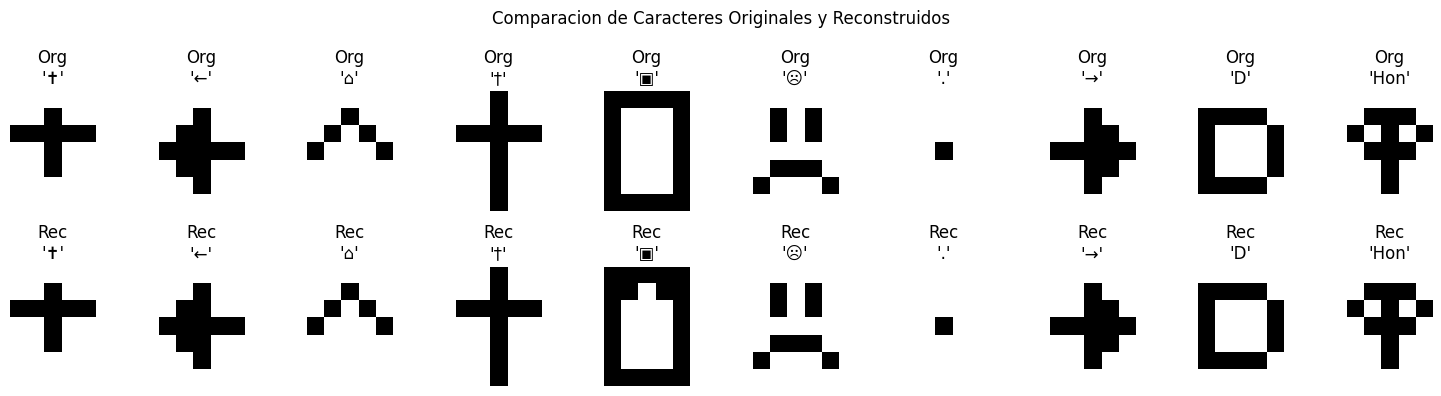

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# AUTOENCODER
# 35 -> 20 -> 10 -> 2 -> 10 -> 20 -> 35

entrada = Input(shape=(35,))

# Encoder
x = Dense(20, activation='tanh')(entrada)
x = Dense(10, activation='tanh')(x)
latente = Dense(2, activation='tanh', name='latent')(x)

# Decoder
x = Dense(10, activation='tanh')(latente)
x = Dense(20, activation='tanh')(x)
salida = Dense(35, activation='sigmoid')(x)

autoencoder = Model(entrada, salida)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

# ==================================
# ENTRENAMIENTO
# ==================================

# Aumentamos las épocas para mejorar la reconstrucción
historia = autoencoder.fit(
    X,
    X,
    epochs=4500,
    verbose=0
)


# ERROR FINAL

mse = autoencoder.evaluate(X, X, verbose=0)
print("\nMSE final:", mse)


# RECONSTRUCCION
reconstruccion = autoencoder.predict(X, verbose=0)

reconstruccion_binaria = (
    reconstruccion > 0.5
).astype(int)

idx_to_display = 1

print(f"\nOriginal (index {idx_to_display}):")
print(X[idx_to_display].reshape(7,5).astype(int))

print(f"\nReconstruccion (index {idx_to_display}):")
print(reconstruccion_binaria[idx_to_display].reshape(7,5))


# ENCODER

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent").output
)

latentes = encoder.predict(X, verbose=0)

print("\nForma espacio latente:")
print(latentes.shape)

# GRAFICO ESPACIO LATENTE

plt.figure(figsize=(10,8))

for i, caracter in enumerate(etiquetas):
    plt.text(
        latentes[i,0],
        latentes[i,1],
        caracter,
        fontsize=14,
        ha='center',
        va='center'
    )

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Espacio Latente - Font4")
plt.grid(True)

# margen fijo para que no corte etiquetas
plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)

plt.show()


# DECODER INDEPENDIENTE
entrada_latente = Input(shape=(2,))

x = autoencoder.layers[4](entrada_latente)
x = autoencoder.layers[5](x)
salida_decoder = autoencoder.layers[6](x)

decoder = Model(
    entrada_latente,
    salida_decoder
)


plt.figure(figsize=(3,4))

plt.imshow(
    reconstruccion_binaria[idx_to_display].reshape(7,5),
    cmap="gray_r"
)

plt.title(f"Caracter Reconstruido ({etiquetas[idx_to_display]}) ")
plt.axis("off")

plt.show()




n_caracteres = 10 # Número de caracteres a mostrar
indices_to_show = np.random.choice(len(X), n_caracteres, replace=False)

plt.figure(figsize=(n_caracteres * 1.5, 4))
for i, idx in enumerate(indices_to_show):
    # Original
    ax = plt.subplot(2, n_caracteres, i + 1)
    plt.imshow(X[idx].reshape(7, 5), cmap='gray_r')
    plt.title(f"Org\n'{etiquetas[idx]}'")
    plt.axis('off')

    # Reconstruido
    ax = plt.subplot(2, n_caracteres, i + 1 + n_caracteres)
    plt.imshow(reconstruccion_binaria[idx].reshape(7, 5), cmap='gray_r')
    plt.title(f"Rec\n'{etiquetas[idx]}'")
    plt.axis('off')

plt.suptitle('Comparacion de Caracteres Originales y Reconstruidos')
print()
plt.tight_layout()

plt.show()

In [ ]:
punto = np.array([[0.5, 0]])


# Decodificar
generado = decoder.predict(
    punto,
    verbose=0
)


# Pasar a binario
generado_binario = (
    generado > 0.5
).astype(int)


print("Punto elegido en espacio latente:")
print(punto)

print("\nCaracter generado:")
print(generado_binario.reshape(7,5))



# MOSTRAR CARACTER GENERADO

plt.figure(figsize=(3,4))

plt.imshow(
    generado_binario.reshape(7,5),
    cmap="gray_r"
)

plt.title(
    f"Generado z=({punto[0,0]:.2f},{punto[0,1]:.2f})"
)

plt.axis("off")
plt.show()



# PLANO LATENTE CON PUNTO NUEVO

plt.figure(figsize=(8,6))


# Mostrar caracteres aprendidos
for i, caracter in enumerate(etiquetas):

    plt.scatter(
        latentes[i,0],
        latentes[i,1],
        s=40
    )

    plt.text(
        latentes[i,0],
        latentes[i,1],
        caracter,
        fontsize=14
    )


# Punto generado
plt.scatter(
    punto[0,0],
    punto[0,1],
    c="red",
    s=200,
    marker="x",
    label="Nuevo caracter"
)


plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Espacio latente con caracter generado")
plt.legend()
plt.grid(True)

plt.show()